# LeetCode #194: Transpose File

https://leetcode.com/problems/transpose-file/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| awk transpose ★ | O(n×m) | O(n×m) |
| Nested loops in bash | O(n×m) | O(n×m) |

## Understanding the Methods
### awk Transpose (Optimal Shell)
Read all fields into a 2D array indexed by row and column. After processing all lines, iterate by column first, then row, to print the transposed output. Uses NF (number of fields) and NR (number of records) to determine dimensions.

### Nested Loops in Bash
Use `cut` or array indexing to extract each column across all rows. More verbose but conceptually straightforward.

## Solutions

### C#

In [ ]:
// Shell Problem — Bash solution using awk:
// awk '{
//     for (i=1; i<=NF; i++) {
//         if (NR==1) s[i]=$i;
//         else s[i]=s[i]" "$i;
//     }
// }
// END {
//     for (i=1; s[i]!=""; i++) print s[i];
// }' file.txt

// C# equivalent:
using System;
using System.IO;
using System.Collections.Generic;

var lines = File.ReadAllLines("file.txt");
var cols = lines[0].Split(' ').Length;
var result = new List<string>();
for (int c = 0; c < cols; c++) {
    var row = new List<string>();
    foreach (var line in lines) {
        var parts = line.Split(' ');
        row.Add(parts[c]);
    }
    result.Add(string.Join(" ", row));
}
foreach (var r in result) Console.WriteLine(r);

### Python

In [ ]:
def transpose_file(filename: str) -> list[str]:
    with open(filename) as f:
        rows = [line.split() for line in f]
    transposed = zip(*rows)
    return [' '.join(col) for col in transposed]

# Usage:
# for line in transpose_file('file.txt'):
#     print(line)

### Go

In [ ]:
package main

import (
    "bufio"
    "fmt"
    "os"
    "strings"
)

func main() {
    file, _ := os.Open("file.txt")
    defer file.Close()
    var rows [][]string
    scanner := bufio.NewScanner(file)
    for scanner.Scan() {
        rows = append(rows, strings.Fields(scanner.Text()))
    }
    if len(rows) == 0 {
        return
    }
    cols := len(rows[0])
    for c := 0; c < cols; c++ {
        var parts []string
        for _, row := range rows {
            parts = append(parts, row[c])
        }
        fmt.Println(strings.Join(parts, " "))
    }
}

### Rust

In [ ]:
use std::io::{self, BufRead};

fn main() {
    let stdin = io::stdin();
    let rows: Vec<Vec<String>> = stdin.lock().lines()
        .map(|l| l.unwrap().split_whitespace().map(String::from).collect())
        .collect();
    if rows.is_empty() {
        return;
    }
    let cols = rows[0].len();
    for c in 0..cols {
        let col: Vec<&str> = rows.iter().map(|row| row[c].as_str()).collect();
        println!("{}", col.join(" "));
    }
}

## Examples

**1. Common Case — 3×2 Matrix**
**Input:** File contains `"name age\nalice 21\nbob 25"`
3 rows × 2 columns → transposed to 2 rows × 3 columns. `"name alice bob\nage 21 25"`.
*Why tricky:* Baseline transpose — rows become columns. Time and space both $O(n \times m)$ where $n = 3, m = 2$.

**2. Slightly Complex — 4×3 Non-Square Matrix**
**Input:** `"a b c\nd e f\ng h i\nj k l"`
4 rows × 3 columns transposes to 3 rows × 4 columns. Output dimensions differ from input: output has $\text{NF}$ rows and $\text{NR}$ columns.
*Why tricky:* Non-square matrix — output shape $\neq$ input shape. NF $= 3$ becomes output row count, NR $= 4$ becomes output column count.

**3. Edge Case: Time Factor — Wide File (1000 columns)**
**Input:** 100 rows × 1000 columns → 100,000 total fields
awk reads all fields into a 2D array. Output = 1000 rows × 100 columns. awk string concatenation `s[i]=s[i]" "$i` is $O(\text{len})$ per append, giving $O(n \times m \times \text{avg\_len})$ total.
*Why tricky:* Wide files make output tall — 1000 output lines. The string concatenation cost can dominate for long field values.

**4. Edge Case: Space Factor — Entire File in Memory**
**Input:** 500 rows × 500 columns, each field 20 chars → 250,000 fields ≈ 5 MB
Transposition cannot be streamed — you must read all input before producing any output. Memory $= O(n \times m)$ is unavoidable.
*Why tricky:* Fundamental limitation — streaming transpose is impossible. All $n \times m$ fields must reside in memory simultaneously.

**5. Almost-Impossible but Plausible — Single Column (n×1 → 1×n)**
**Input:** `"alpha\nbeta\ngamma\ndelta\nepsilon"` — 5 rows × 1 column
Transposes to 1 row × 5 columns: `"alpha beta gamma delta epsilon"`. NF $= 1$ throughout.
*Why tricky:* Degenerate dimension — tests the boundary where $m = 1$. The single output row has $\text{NR} = n$ fields concatenated.

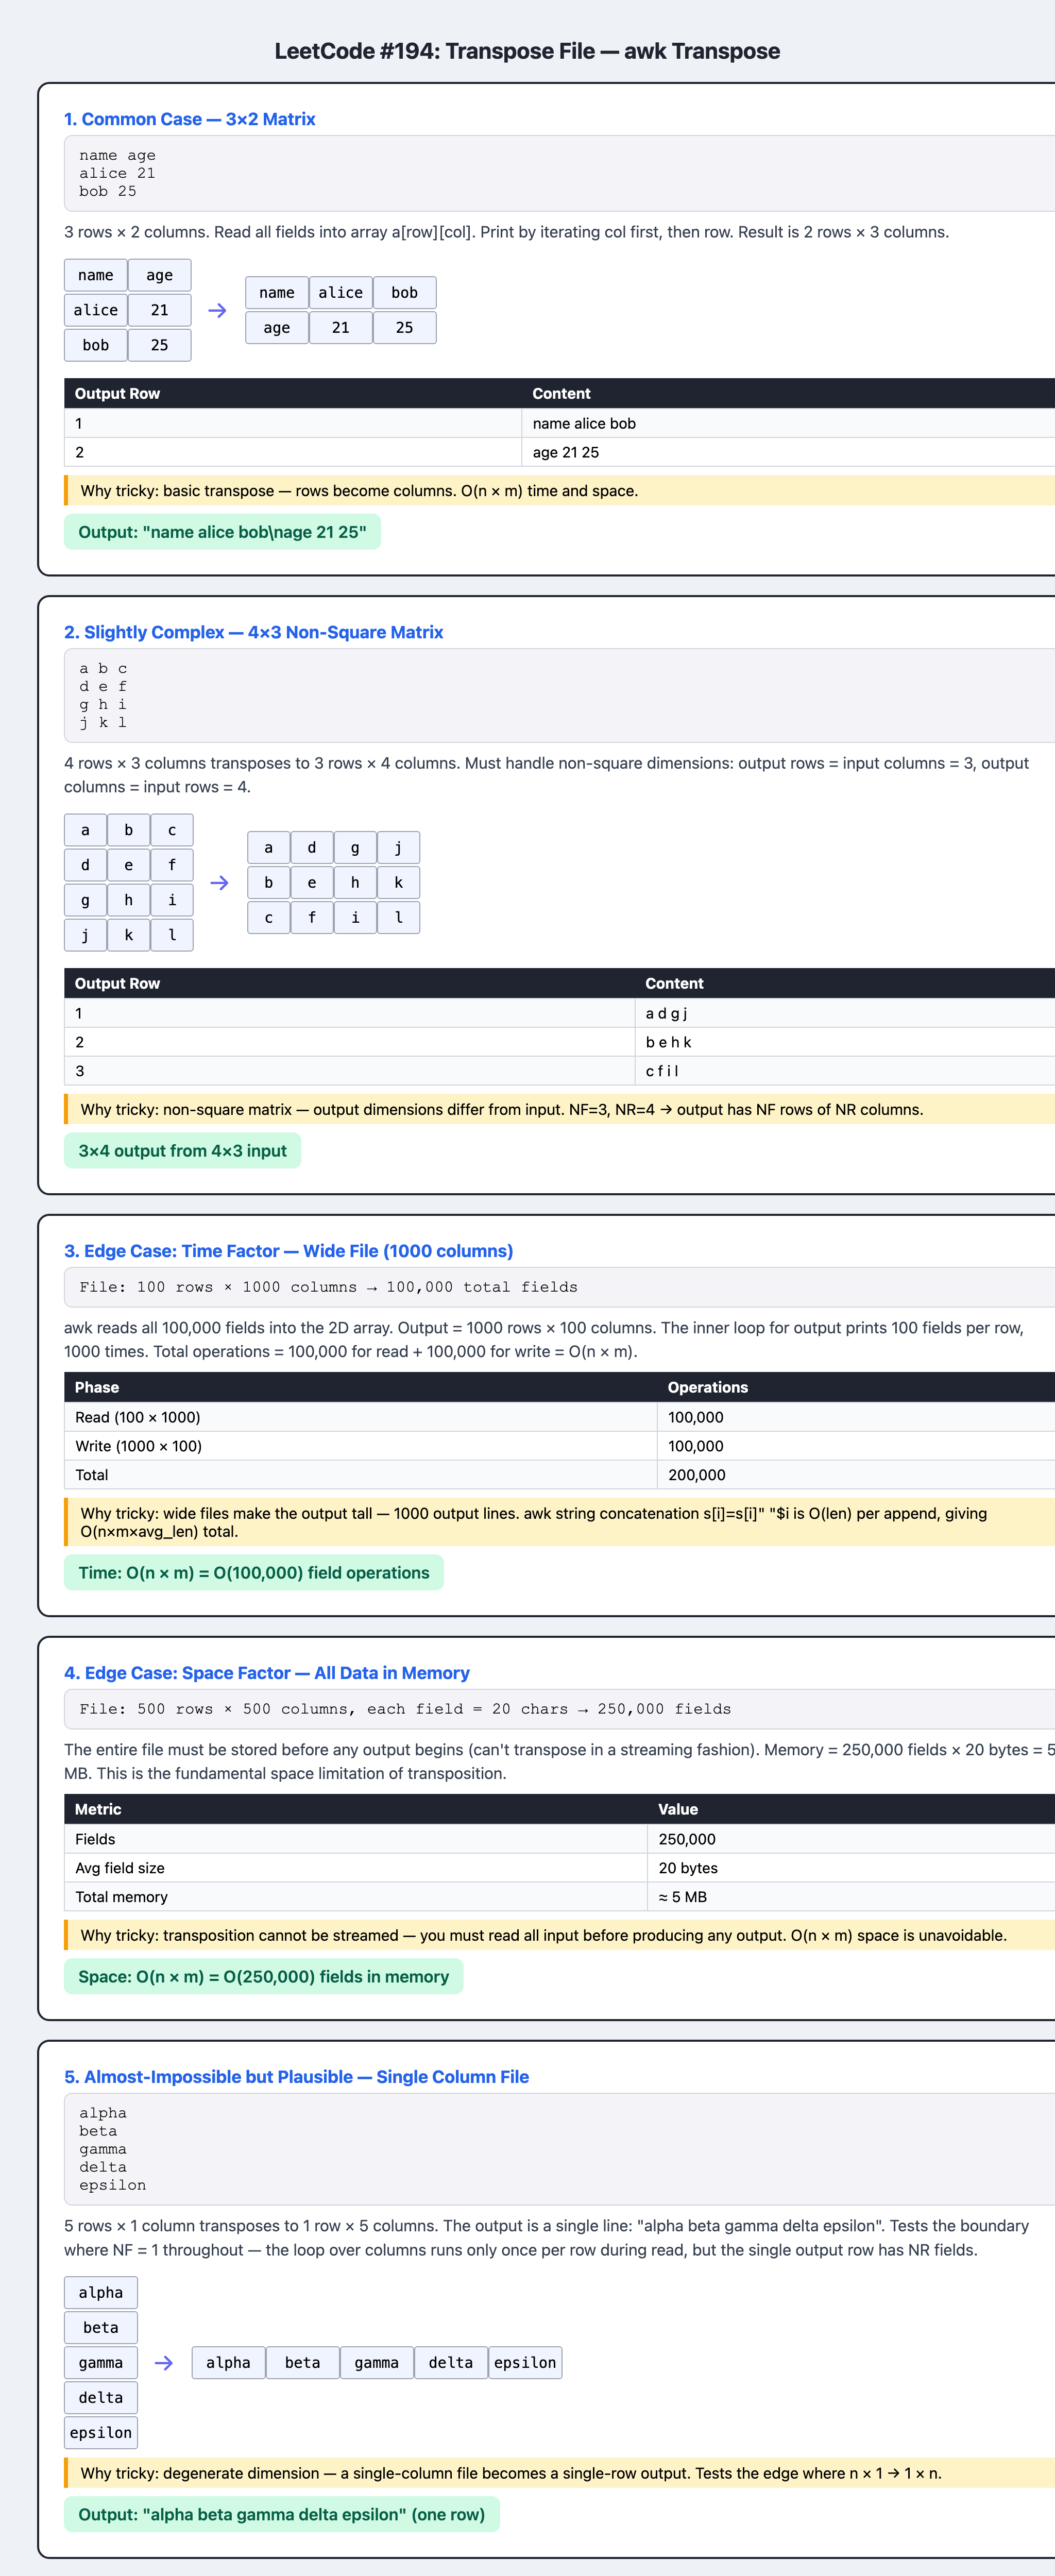